In [2]:
# pip install kagglehub[pandas-datasets]

In [3]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "heart.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "fedesoriano/heart-failure-prediction",
  file_path,
)

print("First 5 records:", df.head())

c:\Users\Chiran\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


First 5 records:    Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
display(df.describe(include='all'))

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


In [6]:
null_values = df.isnull().sum()
features_with_nulls = null_values[null_values > 0]

if not features_with_nulls.empty:
    print("Features with null values:")
    print(features_with_nulls)
else:
    print("No features currently have null values.")


No features currently have null values.


In [7]:
# Impute missing values with the median
df['RestingBP'] = df['RestingBP'].fillna(df['RestingBP'].median())
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].median())

# Verify that there are no more null values
print("Null values after imputation:")
print(df.isnull().sum())

Null values after imputation:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


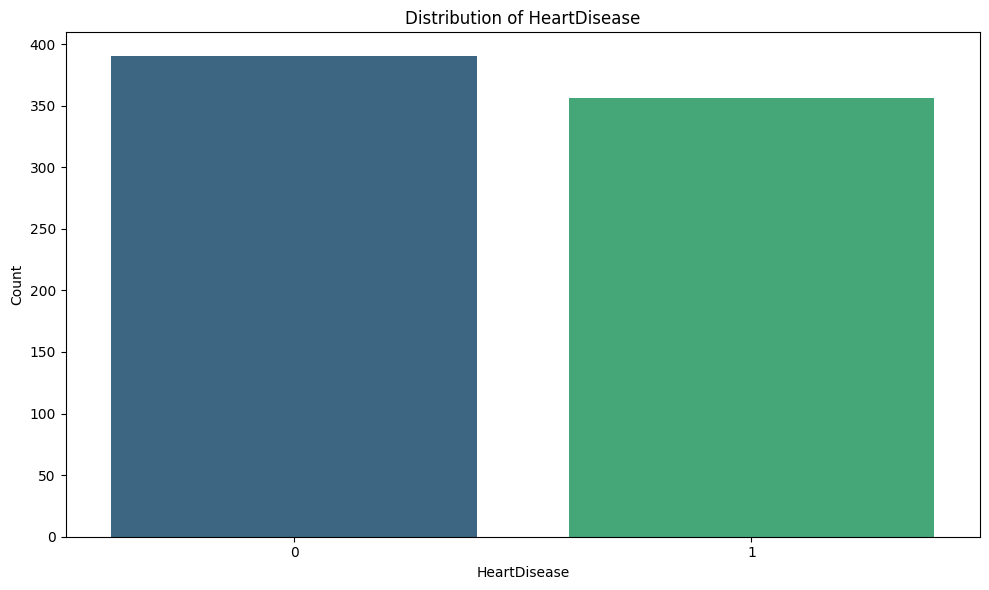

In [26]:
# HeartDisease is the target variable, so we want to see how it's distributed
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# for i, feature in enumerate('HeartDisease'):
plt.subplot(1, 1,  1) # Adjust subplot grid as needed
sns.countplot(x='HeartDisease', data=df, palette='viridis', hue='HeartDisease', legend=False)
plt.title(f'Distribution of HeartDisease')
plt.xlabel('HeartDisease')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

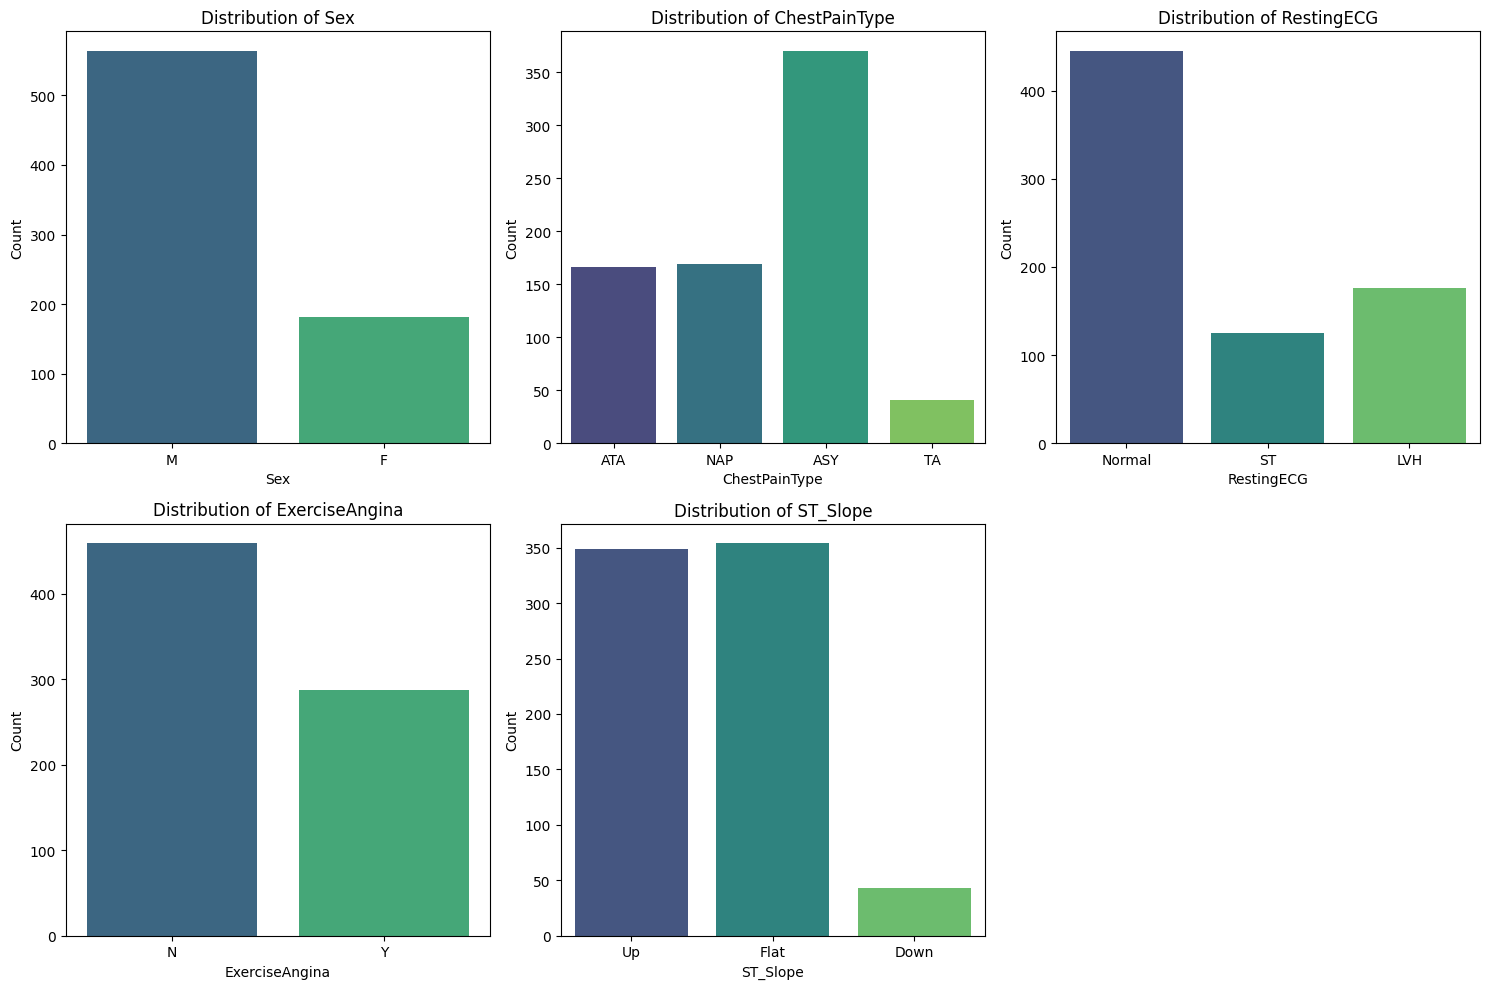

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(categorical_features):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.countplot(x=feature, data=df, palette='viridis', hue=feature, legend=False)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\Chiran\AppData\Local\Temp\ipykernel_24176\1689936045.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x=feature, data=df, kde=True, palette='viridis')
C:\Users\Chiran\AppData\Local\Temp\ipykernel_24176\1689936045.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x=feature, data=df, kde=True, palette='viridis')
C:\Users\Chiran\AppData\Local\Temp\ipykernel_24176\1689936045.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x=feature, data=df, kde=True, palette='viridis')
C:\Users\Chiran\AppData\Local\Temp\ipykernel_24176\1689936045.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(x=feature, data=df, kde=True, palette='viridis')
C:\Users\Chiran\AppData\Local\Temp\ipykernel_24176\1689936045.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot

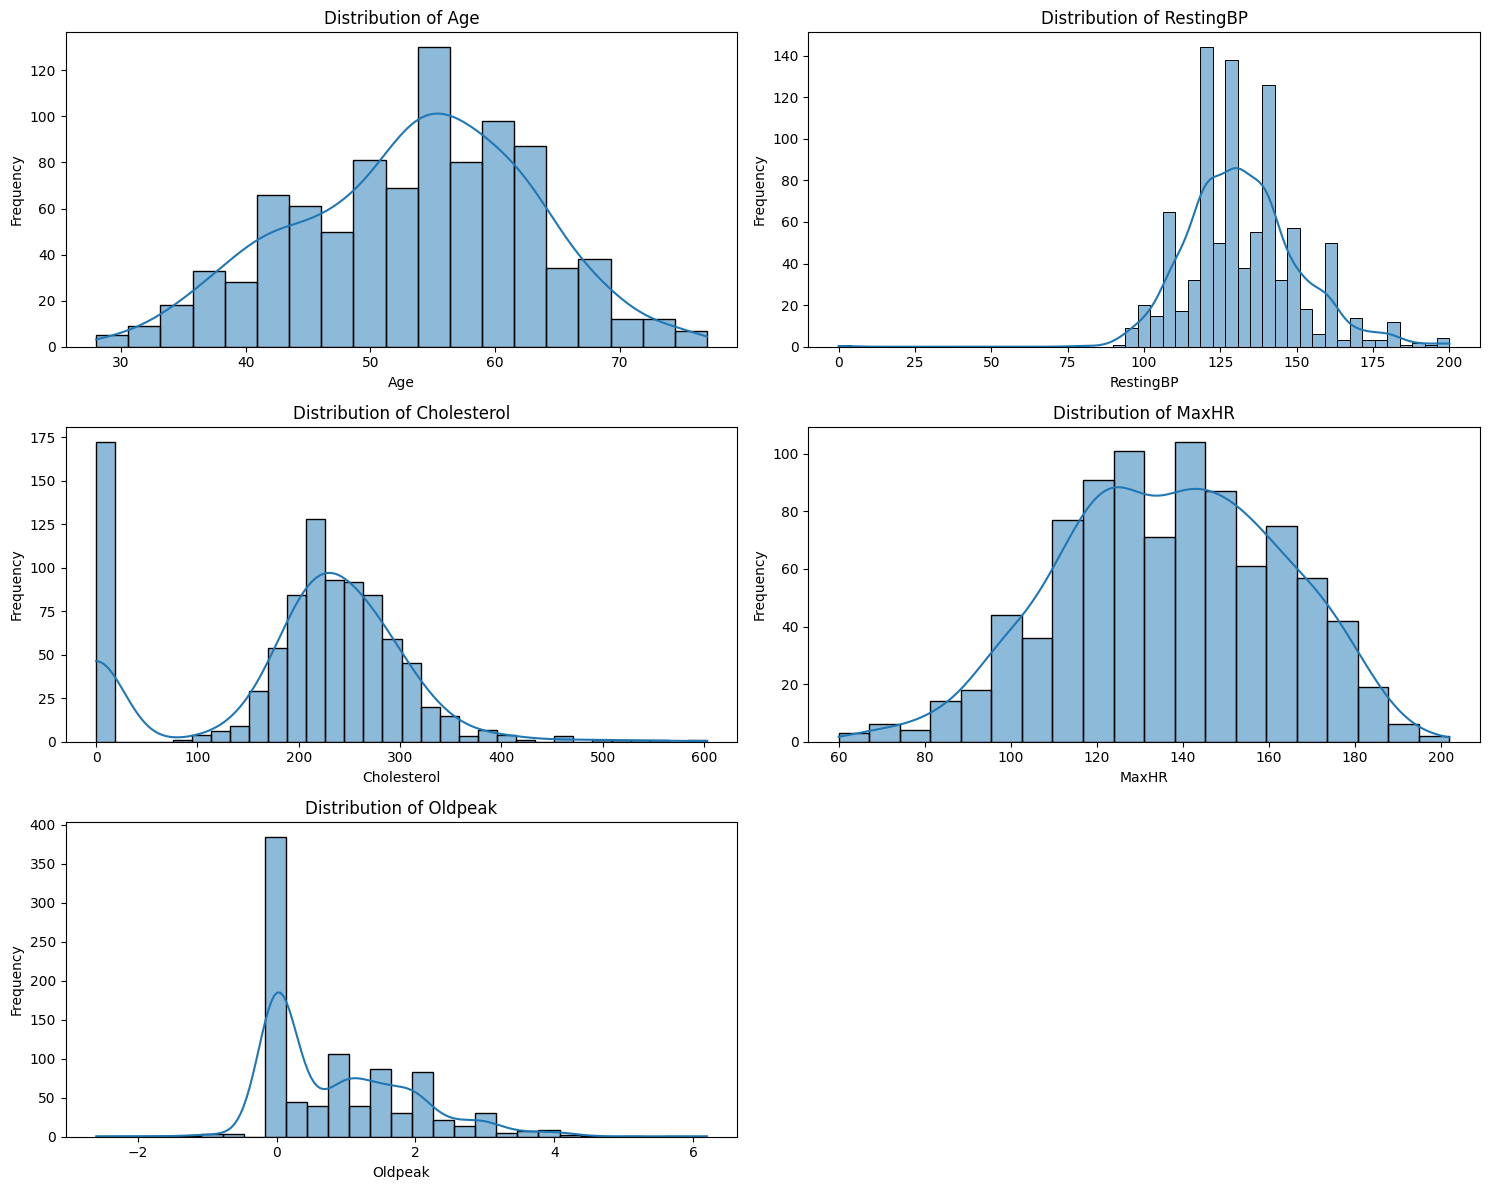

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize continuous numerical features using histograms
continuous_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

plt.figure(figsize=(15, 12))
for i, feature in enumerate(continuous_features):
    plt.subplot(3, 2, i + 1) # Adjust subplot grid as needed
    sns.histplot(x=feature, data=df, kde=True, palette='viridis')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

# Identify non-numerical features to encode
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after one-hot encoding:")
display(df_encoded.head())

# Display information about the new DataFrame to confirm data types and column changes
display(df_encoded.info())

DataFrame after one-hot encoding:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    int64  
 2   Cholesterol        918 non-null    int64  
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   Oldpeak            918 non-null    float64
 6   HeartDisease       918 non-null    int64  
 7   Sex_M              918 non-null    bool   
 8   ChestPainType_ATA  918 non-null    bool   
 9   ChestPainType_NAP  918 non-null    bool   
 10  ChestPainType_TA   918 non-null    bool   
 11  RestingECG_Normal  918 non-null    bool   
 12  RestingECG_ST      918 non-null    bool   
 13  ExerciseAngina_Y   918 non-null    bool   
 14  ST_Slope_Flat      918 non-null    bool   
 15  ST_Slope_Up        918 non-null    bool   
dtypes: bool(9), float64(1), in

None

In [11]:
df[df["Cholesterol"]==0].count()

Age               172
Sex               172
ChestPainType     172
RestingBP         172
Cholesterol       172
FastingBS         172
RestingECG        172
MaxHR             172
ExerciseAngina    172
Oldpeak           172
ST_Slope          172
HeartDisease      172
dtype: int64

In [12]:
df = df.drop(df[df["Cholesterol"]==0].index)

In [13]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000,746.000000
mean,52.882038,133.022788,244.635389,0.167560,140.226542,0.901609,0.477212
std,9.505888,17.282750,59.153524,0.373726,24.524107,1.072861,0.499816
min,28.000000,92.000000,85.000000,0.000000,69.000000,-0.100000,0.000000
25%,46.000000,120.000000,207.250000,0.000000,122.000000,0.000000,0.000000
50%,54.000000,130.000000,237.000000,0.000000,140.000000,0.500000,0.000000
75%,59.000000,140.000000,275.000000,0.000000,160.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [14]:
target = "HeartDisease" 

# Separate input features (X) and target labels (y)
X = df.drop(columns=[target])  # X = all columns except HeartDisease
y = df[target]                 # y = the HeartDisease column only

# Show basic information about the target distribution (class balance)
print("Target value counts (0 = no disease, 1 = disease):")
print(y.value_counts())

# Automatically detect numeric feature columns (int or float)
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Automatically detect categorical feature columns (non-numeric types)
categorical_features = X.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print("\nNumeric feature columns:")
print(numeric_features)

print("\nCategorical feature columns:")
print(categorical_features)

Target value counts (0 = no disease, 1 = disease):
HeartDisease
0    390
1    356
Name: count, dtype: int64

Numeric feature columns:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

Categorical feature columns:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [15]:
# --- Split OFF the Test Set (15%) ---
from sklearn.model_selection import train_test_split


X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,      # 15% for final test
    random_state=42,
    stratify=y           # keep 0/1 ratio consistent
)

# --- From the remaining 85%, split Train and Validation ---
# Validation should be 15% of TOTAL.
# So inside the remaining 85%, validation proportion is:
#       0.15 / 0.85 = ~0.17647
validation_ratio = 0.15 / 0.85  # ~0.17647

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=validation_ratio,  # produces 15% overall validation
    random_state=42,
    stratify=y_temp
)

# Print out the sizes to confirm 70/15/15 split
print("Train set size:     ", X_train.shape[0], "rows")
print("Validation set size:", X_val.shape[0], "rows")
print("Test set size:      ", X_test.shape[0], "rows")

# Optional check: print percentages
total = len(df)
print("\nPercentage breakdown:")
print("Train:      ", round(X_train.shape[0] / total * 100, 2), "%")
print("Validation: ", round(X_val.shape[0] / total * 100, 2), "%")
print("Test:       ", round(X_test.shape[0] / total * 100, 2), "%")

Train set size:      522 rows
Validation set size: 112 rows
Test set size:       112 rows

Percentage breakdown:
Train:       69.97 %
Validation:  15.01 %
Test:        15.01 %


In [16]:
# Pipeline for numeric features: apply StandardScaler
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())  # scale each numeric column to mean=0, std=1
])

# Pipeline for categorical features: apply OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
    # OneHotEncoder:
    # - turns each category value into a binary column (0/1)
    # - handle_unknown="ignore" avoids errors if an unseen category appears in val/test
])

# Combine both numeric and categorical transformers into a single ColumnTransformer
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),        # apply numeric_transformer to numeric_features list
        ("cat", categorical_transformer, categorical_features) # apply categorical_transformer to categorical_features list
    ]
)

# Print a message so we know preprocessing is configured
print("Preprocessing pipeline created.")
print(" - Numeric columns will be scaled.")
print(" - Categorical columns will be one-hot encoded.")

Preprocessing pipeline created.
 - Numeric columns will be scaled.
 - Categorical columns will be one-hot encoded.


LogisticRegression

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

#Create the Logistic Regression model
log_reg_model = LogisticRegression(
    max_iter=1000,   # allow more iterations so it can converge
    solver="lbfgs"   # default solver for small/medium datasets, works fine here
)

# Build the full pipeline: preprocessing + model
log_reg_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),     # first apply our preprocessing (scaler + one-hot)
    ("model", log_reg_model)        # then apply Logistic Regression on the transformed features
])

# Fit the pipeline on the TRAINING data
log_reg_pipeline.fit(X_train, y_train)  # the pipeline will:
                                       # - fit the preprocessors using X_train
                                       # - fit the Logistic Regression model on the transformed X_train

# Use the trained pipeline to make predictions on the VALIDATION set
y_val_pred_log_reg = log_reg_pipeline.predict(X_val)

# Evaluate performance on the VALIDATION set
val_accuracy_log_reg = accuracy_score(y_val, y_val_pred_log_reg)  # compute accuracy

print("Logistic Regression – Validation accuracy:", val_accuracy_log_reg)
print("\nClassification report (Validation set):")
print(classification_report(y_val, y_val_pred_log_reg))

Logistic Regression – Validation accuracy: 0.8392857142857143

Classification report (Validation set):
              precision    recall  f1-score   support

           0       0.88      0.79      0.84        58
           1       0.80      0.89      0.84        54

    accuracy                           0.84       112
   macro avg       0.84      0.84      0.84       112
weighted avg       0.84      0.84      0.84       112



Support Vector Machine model

In [ ]:
from sklearn.svm import SVC

# Create the Support Vector Machine model
svm_model = SVC(random_state=42)

# Build the full pipeline: preprocessing + model
svm_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),     # first apply our preprocessing
    ("model", svm_model)           # then apply SVM
])

# Fit the pipeline on the TRAINING data
svm_pipeline.fit(X_train, y_train)

# Use the trained pipeline to make predictions on the VALIDATION set
y_val_pred_svm = svm_pipeline.predict(X_val)

# Evaluate performance on the VALIDATION set
val_accuracy_svm = accuracy_score(y_val, y_val_pred_svm)

print("Support Vector Machine – Validation accuracy:", val_accuracy_svm)
print("\nClassification report (Validation set):")
print(classification_report(y_val, y_val_pred_svm))

Support Vector Machine – Validation accuracy: 0.8660714285714286

Classification report (Validation set):
              precision    recall  f1-score   support

           0       0.91      0.83      0.86        58
           1       0.83      0.91      0.87        54

    accuracy                           0.87       112
   macro avg       0.87      0.87      0.87       112
weighted avg       0.87      0.87      0.87       112



Decision Tree Classifier model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree Classifier model
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Build the full pipeline: preprocessing + model
decision_tree_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),     # first apply our preprocessing
    ("model", decision_tree_model)  # then apply Decision Tree
])

# Fit the pipeline on the TRAINING data
decision_tree_pipeline.fit(X_train, y_train)

# Use the trained pipeline to make predictions on the VALIDATION set
y_val_pred_dt = decision_tree_pipeline.predict(X_val)

# Evaluate performance on the VALIDATION set
val_accuracy_dt = accuracy_score(y_val, y_val_pred_dt)

print("Decision Tree Classifier – Validation accuracy:", val_accuracy_dt)
print("\nClassification report (Validation set):")
print(classification_report(y_val, y_val_pred_dt))

Decision Tree Classifier – Validation accuracy: 0.7946428571428571

Classification report (Validation set):
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        58
           1       0.78      0.80      0.79        54

    accuracy                           0.79       112
   macro avg       0.79      0.79      0.79       112
weighted avg       0.79      0.79      0.79       112



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest Classifier model
random_forest_model = RandomForestClassifier(random_state=42)

# Build the full pipeline: preprocessing + model
random_forest_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),     # first apply our preprocessing
    ("model", random_forest_model)  # then apply Random Forest
])

# Fit the pipeline on the TRAINING data
random_forest_pipeline.fit(X_train, y_train)

# Use the trained pipeline to make predictions on the VALIDATION set
y_val_pred_rf = random_forest_pipeline.predict(X_val)

# Evaluate performance on the VALIDATION set
val_accuracy_rf = accuracy_score(y_val, y_val_pred_rf)

print("Random Forest Classifier – Validation accuracy:", val_accuracy_rf)
print("\nClassification report (Validation set):")
print(classification_report(y_val, y_val_pred_rf))

Random Forest Classifier – Validation accuracy: 0.8392857142857143

Classification report (Validation set):
              precision    recall  f1-score   support

           0       0.87      0.81      0.84        58
           1       0.81      0.87      0.84        54

    accuracy                           0.84       112
   macro avg       0.84      0.84      0.84       112
weighted avg       0.84      0.84      0.84       112

